# Notebook para análise exploratória dos dados unificados

## Dataframe antes da limpeza:

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Define o path do CSV unificado
script_dir = Path.cwd()
data_dir = script_dir.parent / "data"
csv_path = data_dir / "unified_dataframe.csv"

<class 'pandas.DataFrame'>
DatetimeIndex: 3653 entries, 2016-01-01 to 2025-12-31
Data columns (total 43 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   BTC_Open                      3653 non-null   float64
 1   BTC_High                      3653 non-null   float64
 2   BTC_Low                       3653 non-null   float64
 3   BTC_Close                     3653 non-null   float64
 4   BTC_Volume                    3653 non-null   int64  
 5   US_FEDFUNDS                   3653 non-null   float64
 6   US_FEDFUNDS_DAILY             3653 non-null   float64
 7   US_CPI                        3653 non-null   float64
 8   US_10Y                        3650 non-null   float64
 9   ECB_MAIN_REFINANCING          3653 non-null   float64
 10  GERMANY_CPI                   3653 non-null   float64
 11  FRANCE_CPI                    3653 non-null   float64
 12  ITALY_CPI                     3653 non-null   float64
 

,BTC_Open,BTC_High,BTC_Low,BTC_Close,BTC_Volume,US_FEDFUNDS,US_FEDFUNDS_DAILY,US_CPI,US_10Y,ECB_MAIN_REFINANCING,...,USD_JPY,USD_CNY,NIFTY_50,IBOVESPA,USD_BRL,USD_ZAR,UK_POLICY_RATE,CANADA_POLICY_RATE,BRAZIL_SELIC,CANADA_CPI
count,3653.000000,3653.000000,3653.000000,3653.000000,3.653000e+03,3653.000000,3653.000000,3653.000000,3650.000000,3653.000000,...,3653.000000,3653.000000,3650.000000,3650.000000,3653.000000,3653.000000,3650.000000,3653.000000,3653.000000,3653.000000
mean,30249.572502,30858.827935,29606.180590,30272.254452,2.441560e+10,2.191528,2.190942,275.501279,2.697263,1.093964,...,122.989730,6.844391,15122.876273,100997.699178,4.594266,15.777577,1.789301,1.908842,9.557419,144.018834
std,32057.275563,32597.029482,31481.900581,32066.790421,2.287680e+10,1.907198,1.909834,28.892672,1.173855,1.647830,...,18.067245,0.293810,5625.048792,26380.946413,0.909113,2.040200,1.973974,1.632782,4.184667,12.637121
min,365.072998,374.950012,354.914001,364.330994,2.851400e+07,0.050000,0.040000,237.336000,0.520000,0.000000,...,99.905998,6.267600,6970.600098,37497.000000,3.056100,11.563800,0.100000,0.250000,2.000000,126.800000
25%,6413.629883,6535.410156,6316.879883,6416.314941,5.302482e+09,0.380000,0.370000,251.214000,1.740000,0.000000,...,109.080002,6.585400,10472.500000,79646.000000,3.750400,14.180800,0.250000,0.500000,6.500000,133.500000
50%,17128.894531,17567.699219,16812.369141,17130.486328,2.049660e+10,1.690000,1.690000,262.045000,2.550000,0.000000,...,112.875000,6.877500,13902.899902,105515.000000,4.953800,15.297390,0.750000,1.500000,10.500000,137.700000
75%,46415.898438,47510.726562,45235.816406,46453.566406,3.557456e+10,4.330000,4.330000,304.609000,3.860000,2.150000,...,142.772995,7.108500,19047.250000,120171.500000,5.360600,17.725130,4.000000,3.000000,13.750000,158.100000
max,124752.140625,126198.070312,123196.046875,124752.531250,3.509679e+11,5.330000,5.330000,326.031000,4.980000,4.500000,...,161.621002,7.350000,26216.050781,164456.000000,6.300000,19.774500,5.250000,5.000000,15.000000,165.400000



Dias duplicados no índice: 0
Colunas com valores constantes: []


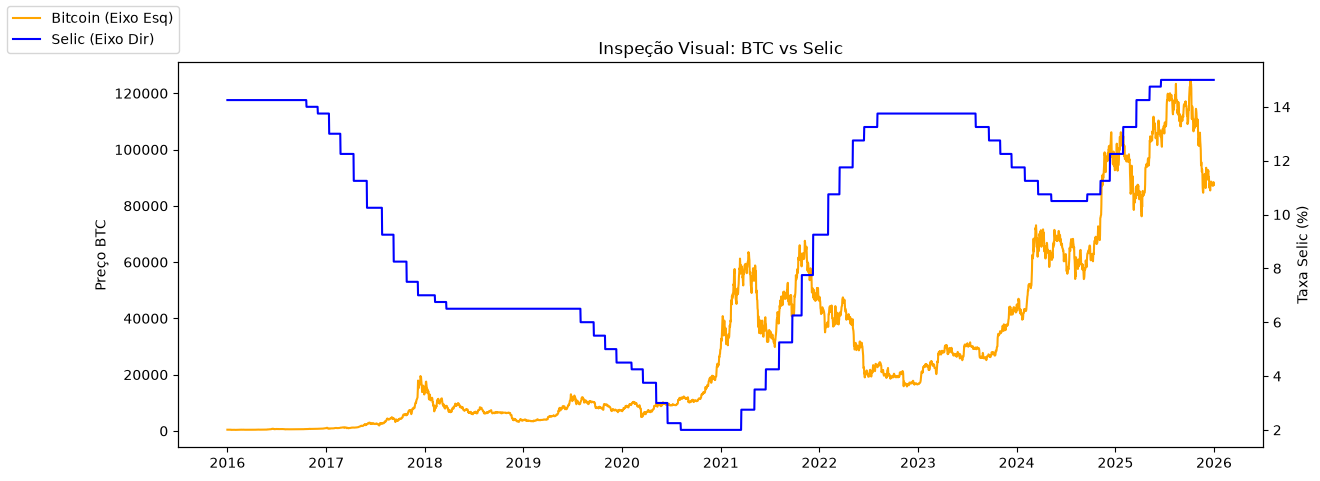

In [2]:
# Carrega o dataset 
df = pd.read_csv(csv_path, index_col="Date", parse_dates=True)

# Visão geral dos tipos de dados (tudo deve ser float ou int)
print(df.info())

# Resumo estatístico (olhe para os valores 'min' e 'max' para achar absurdos)
display(df.describe())

# Verifica se há dias duplicados no índice
duplicados = df.index.duplicated().sum()
print(f"\nDias duplicados no índice: {duplicados}")

# Verifica colunas que ficaram com variância zero (ficaram constantes)
constantes = [col for col in df.columns if df[col].nunique() == 1]
print(f"Colunas com valores constantes: {constantes}")

# Plota algumas variáveis para inspeção visual (ex: Bitcoin vs Selic)
fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.plot(df.index, df['BTC_Close'], color='orange', label='Bitcoin (Eixo Esq)')
ax1.set_ylabel('Preço BTC')

ax2 = ax1.twinx()
ax2.plot(df.index, df['BRAZIL_SELIC'], color='blue', label='Selic (Eixo Dir)')
ax2.set_ylabel('Taxa Selic (%)')

fig.legend(loc="upper left")
plt.title("Inspeção Visual: BTC vs Selic")
plt.show()

In [3]:
summary_df = pd.DataFrame({
    "coluna": df.columns,
    "min": df.min().values,
    "max": df.max().values
})

display(summary_df)

,coluna,min,max
0,BTC_Open,3.650730e+02,1.247521e+05
1,BTC_High,3.749500e+02,1.261981e+05
2,BTC_Low,3.549140e+02,1.231960e+05
3,BTC_Close,3.643310e+02,1.247525e+05
4,BTC_Volume,2.851400e+07,3.509679e+11
5,US_FEDFUNDS,5.000000e-02,5.330000e+00
6,US_FEDFUNDS_DAILY,4.000000e-02,5.330000e+00
7,US_CPI,2.373360e+02,3.260310e+02
8,US_10Y,5.200000e-01,4.980000e+00
9,ECB_MAIN_REFINANCING,0.000000e+00,4.500000e+00


In [4]:
# Total e Percentual de Nulos por Coluna
nulos_resumo = pd.DataFrame({
    'Total Nulos': df.isna().sum(),
    'Percentual (%)': (df.isna().sum() / len(df)) * 100
})
# Filtra apenas as colunas que têm algum nulo
nulos_resumo = nulos_resumo[nulos_resumo['Total Nulos'] > 0].sort_values(by='Total Nulos', ascending=False)
print("--- RESUMO DE VALORES NULOS ---")
display(nulos_resumo)

# Onde esses nulos estão? (Identificando as datas problemáticas)
linhas_com_nulos = df[df.isna().any(axis=1)]
print(f"\nTotal de linhas afetadas por nulos: {len(linhas_com_nulos)}")
print("\nPrimeiras datas com nulos (Geralmente 2016):")
display(linhas_com_nulos.head())
print("\nÚltimas datas com nulos (Geralmente datas recentes):")
display(linhas_com_nulos.tail())

display(df)

--- RESUMO DE VALORES NULOS ---


,Total Nulos,Percentual (%)
US_10Y,3,0.082124
US_DXY,3,0.082124
NASDAQ_100,3,0.082124
DAX,3,0.082124
CAC_40,3,0.082124
FTSE_MIB,3,0.082124
FTSE_100,3,0.082124
SP_TSX,3,0.082124
NIKKEI_225,3,0.082124
NIFTY_50,3,0.082124



Total de linhas afetadas por nulos: 3

Primeiras datas com nulos (Geralmente 2016):


,BTC_Open,BTC_High,BTC_Low,BTC_Close,BTC_Volume,US_FEDFUNDS,US_FEDFUNDS_DAILY,US_CPI,US_10Y,ECB_MAIN_REFINANCING,...,USD_JPY,USD_CNY,NIFTY_50,IBOVESPA,USD_BRL,USD_ZAR,UK_POLICY_RATE,CANADA_POLICY_RATE,BRAZIL_SELIC,CANADA_CPI
Date,,,,,,,,,,,,,,,,,,,,,
2016-01-01,430.721008,436.246002,427.515015,434.334015,36278900,0.34,0.2,237.652,NaN,0.05,...,120.288002,6.4837,NaN,NaN,3.95,15.46,NaN,0.5,14.25,126.8
2016-01-02,434.622009,436.062012,431.869995,433.437988,30096600,0.34,0.2,237.652,NaN,0.05,...,120.288002,6.4837,NaN,NaN,3.95,15.46,NaN,0.5,14.25,126.8
2016-01-03,433.578003,433.743011,424.705994,430.010986,39633800,0.34,0.2,237.652,NaN,0.05,...,120.288002,6.4837,NaN,NaN,3.95,15.46,NaN,0.5,14.25,126.8



Últimas datas com nulos (Geralmente datas recentes):


,BTC_Open,BTC_High,BTC_Low,BTC_Close,BTC_Volume,US_FEDFUNDS,US_FEDFUNDS_DAILY,US_CPI,US_10Y,ECB_MAIN_REFINANCING,...,USD_JPY,USD_CNY,NIFTY_50,IBOVESPA,USD_BRL,USD_ZAR,UK_POLICY_RATE,CANADA_POLICY_RATE,BRAZIL_SELIC,CANADA_CPI
Date,,,,,,,,,,,,,,,,,,,,,
2016-01-01,430.721008,436.246002,427.515015,434.334015,36278900,0.34,0.2,237.652,NaN,0.05,...,120.288002,6.4837,NaN,NaN,3.95,15.46,NaN,0.5,14.25,126.8
2016-01-02,434.622009,436.062012,431.869995,433.437988,30096600,0.34,0.2,237.652,NaN,0.05,...,120.288002,6.4837,NaN,NaN,3.95,15.46,NaN,0.5,14.25,126.8
2016-01-03,433.578003,433.743011,424.705994,430.010986,39633800,0.34,0.2,237.652,NaN,0.05,...,120.288002,6.4837,NaN,NaN,3.95,15.46,NaN,0.5,14.25,126.8


,BTC_Open,BTC_High,BTC_Low,BTC_Close,BTC_Volume,US_FEDFUNDS,US_FEDFUNDS_DAILY,US_CPI,US_10Y,ECB_MAIN_REFINANCING,...,USD_JPY,USD_CNY,NIFTY_50,IBOVESPA,USD_BRL,USD_ZAR,UK_POLICY_RATE,CANADA_POLICY_RATE,BRAZIL_SELIC,CANADA_CPI
Date,,,,,,,,,,,,,,,,,,,,,
2016-01-01,430.721008,436.246002,427.515015,434.334015,36278900,0.34,0.20,237.652,NaN,0.05,...,120.288002,6.4837,NaN,NaN,3.9500,15.460000,NaN,0.50,14.25,126.8
2016-01-02,434.622009,436.062012,431.869995,433.437988,30096600,0.34,0.20,237.652,NaN,0.05,...,120.288002,6.4837,NaN,NaN,3.9500,15.460000,NaN,0.50,14.25,126.8
2016-01-03,433.578003,433.743011,424.705994,430.010986,39633800,0.34,0.20,237.652,NaN,0.05,...,120.288002,6.4837,NaN,NaN,3.9500,15.460000,NaN,0.50,14.25,126.8
2016-01-04,430.061005,434.516998,429.084015,433.091003,38477500,0.34,0.36,237.652,2.24,0.05,...,120.310997,6.4837,7791.299805,42141.0,3.9491,15.460640,0.50,0.50,14.25,126.8
2016-01-05,433.069000,434.182007,429.675995,431.959991,34522600,0.34,0.36,237.652,2.25,0.05,...,119.467003,6.5254,7784.649902,42419.0,4.0373,15.523000,0.50,0.50,14.25,126.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-27,87301.429688,87874.781250,87182.976562,87802.156250,13741199310,3.72,3.64,326.031,4.14,2.15,...,156.089996,7.0280,26042.300781,160897.0,5.5195,16.627199,3.75,2.25,15.00,165.0
2025-12-28,87799.343750,87986.890625,87394.953125,87835.835938,15156557929,3.72,3.64,326.031,4.14,2.15,...,156.089996,7.0280,26042.300781,160897.0,5.5195,16.627199,3.75,2.25,15.00,165.0
2025-12-29,87835.789062,90299.156250,86717.914062,87138.140625,48411625849,3.72,3.64,326.031,4.12,2.15,...,156.462997,7.0280,25942.099609,160490.0,5.5425,16.659201,3.75,2.25,15.00,165.0


## Análise exploratória do dataframe clean

#### Baixando o dataframe clean da nuvem (HuggingFace) - caso necessário

In [5]:
from datasets import load_dataset
import pandas as pd

def download_from_huggingface():
    """
    Baixa o dataset financeiro do Hugging Face e 
    formata para o padrão Pandas (DatetimeIndex).
    """

    repo_id = "leodemore/btc-finance-historical-data"
    print(f"Baixando dados de: {repo_id}...")

    # Baixa o dataset do Hub
    dataset = load_dataset(repo_id)
    
    # Converte para um DataFrame do Pandas
    df = dataset['train'].to_pandas()
    
    # Restaura o formato original da coluna de Data
    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True)
    
    print("Download concluído! Dimensões do dataset:", df.shape)
    
    return df

/home/leodemore/GitHub/MADES/MADES/sources/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### Análise exploratória

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

df = download_from_huggingface()
display(df)

Baixando dados de: leodemore/btc-finance-historical-data...


Download concluído! Dimensões do dataset: (3650, 45)


,index,Unnamed: 0,BTC_Open,BTC_High,BTC_Low,BTC_Close,BTC_Volume,US_FEDFUNDS,US_FEDFUNDS_DAILY,US_CPI,...,USD_JPY,USD_CNY,NIFTY_50,IBOVESPA,USD_BRL,USD_ZAR,UK_POLICY_RATE,CANADA_POLICY_RATE,BRAZIL_SELIC,CANADA_CPI
Date,,,,,,,,,,,,,,,,,,,,,
2016-01-04,0,3,430.061005,434.516998,429.084015,433.091003,38477500,0.34,0.36,237.652,...,120.310997,6.4837,7791.299805,42141.0,3.9491,15.460640,0.50,0.50,14.25,126.8
2016-01-05,1,4,433.069000,434.182007,429.675995,431.959991,34522600,0.34,0.36,237.652,...,119.467003,6.5254,7784.649902,42419.0,4.0373,15.523000,0.50,0.50,14.25,126.8
2016-01-06,2,5,431.855988,431.855988,426.341003,429.105011,34042500,0.34,0.36,237.652,...,119.101997,6.5125,7741.000000,41773.0,4.0269,15.637650,0.50,0.50,14.25,126.8
2016-01-07,3,6,430.010986,458.765991,429.076996,458.048004,87562200,0.34,0.36,237.652,...,118.610001,6.5467,7568.299805,40695.0,4.0199,15.857880,0.50,0.50,14.25,126.8
2016-01-08,4,7,457.537994,462.933990,447.937988,453.230011,56993000,0.34,0.36,237.652,...,117.540001,6.5829,7601.350098,40612.0,4.0415,16.058680,0.50,0.50,14.25,126.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-27,3645,3648,87301.429688,87874.781250,87182.976562,87802.156250,13741199310,3.72,3.64,326.031,...,156.089996,7.0280,26042.300781,160897.0,5.5195,16.627199,3.75,2.25,15.00,165.0
2025-12-28,3646,3649,87799.343750,87986.890625,87394.953125,87835.835938,15156557929,3.72,3.64,326.031,...,156.089996,7.0280,26042.300781,160897.0,5.5195,16.627199,3.75,2.25,15.00,165.0
2025-12-29,3647,3650,87835.789062,90299.156250,86717.914062,87138.140625,48411625849,3.72,3.64,326.031,...,156.462997,7.0280,25942.099609,160490.0,5.5425,16.659201,3.75,2.25,15.00,165.0


### 0. Configuração da EDA

O dataset do HuggingFace traz duas colunas que são apenas índices da exportação (`index` e `Unnamed: 0`), que são descartadas.
Nenhum outro pré-processamento é feito nos dados: as transformações abaixo (retornos, agregação mensal) são **visões** do df, e o df original fica como está.

Convenções usadas em todos os testes:
- nível de significância **α = 0,05**;
- retornos são **log-retornos** $r_t = \ln(P_t / P_{t-1})$;
- como os retornos têm caudas pesadas (ver H1), dou preferência a testes **não paramétricos** (Spearman, Kruskal-Wallis, Levene).

In [7]:
import numpy as np
import matplotlib.dates as mdates
from scipy import stats
from statsmodels.tsa.stattools import adfuller, kpss, grangercausalitytests
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.graphics.tsaplots import plot_acf
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
pd.set_option("display.max_columns", 60)

df = df.drop(columns=["index", "Unnamed: 0"], errors="ignore")

ALPHA = 0.05

# Paleta categórica fixa (ordem nunca muda) + tema com grade discreta
C = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
GRAY = "#8a8985"
CMAP_DIV = sns.diverging_palette(250, 15, s=75, l=50, center="light", as_cmap=True)
sns.set_theme(style="whitegrid", rc={
    "axes.prop_cycle": plt.cycler(color=C), "axes.edgecolor": "#d6d5d0", "grid.color": "#ecebe7",
    "axes.titleweight": "bold", "axes.titlesize": 12, "axes.labelcolor": "#52514e",
    "xtick.color": "#52514e", "ytick.color": "#52514e", "lines.linewidth": 1.6,
    "axes.spines.top": False, "axes.spines.right": False, "figure.dpi": 100,
})

def veredito(p, h0):
    """Imprime a decisão de um teste de hipótese de forma padronizada."""
    decisao = "REJEITA H0" if p < ALPHA else "NÃO rejeita H0"
    print(f"   H0: {h0}\n   p-valor = {p:.4g} -> {decisao} (α = {ALPHA})")

print("Dimensões:", df.shape)
print("Período:", df.index.min().date(), "a", df.index.max().date())

Dimensões: (3650, 43)
Período: 2016-01-04 a 2025-12-31


### 1. Estrutura e qualidade dos dados

As 43 variáveis se dividem em grupos com **frequências de origem diferentes**, o que é decisivo para a análise:

| Grupo | Variáveis | Frequência real |
|---|---|---|
| Bitcoin | `BTC_Open/High/Low/Close/Volume` | diária, 7 dias por semana |
| Índices de ações | Nasdaq 100, DAX, CAC 40, FTSE MIB, FTSE 100, S&P/TSX, Nikkei 225, Nifty 50, Ibovespa | dias úteis (fim de semana repetido) |
| Câmbio e dólar | `US_DXY`, `GBP_USD`, `USD_CAD`, `USD_JPY`, `USD_CNY`, `USD_BRL`, `USD_ZAR` | dias úteis |
| Juros | Fed Funds, Treasury 10Y, BCE, BoE, BoC, Selic, interbancários de Japão, China, Índia e África do Sul | mensal ou por decisão de política monetária |
| Inflação (CPI) | EUA, Alemanha, França, Itália, Reino Unido, Japão, China, Índia, Brasil, África do Sul, Canadá | mensal |

In [8]:
grupos = {
    "Bitcoin": [c for c in df.columns if c.startswith("BTC_")],
    "Índices": ["NASDAQ_100", "DAX", "CAC_40", "FTSE_MIB", "FTSE_100", "SP_TSX", "NIKKEI_225", "NIFTY_50", "IBOVESPA"],
    "Câmbio": ["US_DXY", "GBP_USD", "USD_CAD", "USD_JPY", "USD_CNY", "USD_BRL", "USD_ZAR"],
    "Juros": ["US_FEDFUNDS", "US_FEDFUNDS_DAILY", "US_10Y", "ECB_MAIN_REFINANCING", "UK_POLICY_RATE", "CANADA_POLICY_RATE",
              "BRAZIL_SELIC", "JAPAN_INTERBANK_RATE", "CHINA_INTERBANK_RATE", "INDIA_CALL_MONEY_RATE", "SOUTH_AFRICA_CALL_MONEY_RATE"],
    "Inflação": [c for c in df.columns if c.endswith("_CPI")],
}
assert sum(len(v) for v in grupos.values()) == df.shape[1]

qualidade = pd.DataFrame({
    "grupo": {c: g for g, cols in grupos.items() for c in cols},
    "nulos": df.isna().sum(),
    "valores_unicos": df.nunique(),
    # fração de dias em que o valor não muda: revela a frequência real da série
    "pct_dias_sem_variacao": (df.diff().iloc[1:] == 0).mean() * 100,
}).loc[df.columns]

print("Total de nulos:", int(df.isna().sum().sum()))
print("Datas duplicadas:", df.index.duplicated().sum())
print("Intervalos entre datas:", df.index.to_series().diff().value_counts().to_dict())
display(qualidade.groupby("grupo")[["valores_unicos", "pct_dias_sem_variacao"]].median().round(1))

Total de nulos: 0
Datas duplicadas: 0
Intervalos entre datas: {Timedelta('1 days 00:00:00'): 3649}


,valores_unicos,pct_dias_sem_variacao
grupo,,
Bitcoin,"3,649.0000",0.0000
Câmbio,"2,356.0000",28.9000
Inflação,91.0000,97.3000
Juros,41.0000,98.6000
Índices,"2,443.0000",31.1000


**Leitura:** o df está completo (sem nulos, sem duplicatas, sem lacunas no calendário). Porém:
- nos **índices e câmbio**, cerca de 30% dos dias não têm variação: são os fins de semana e feriados repetidos. Por isso, comparações de retorno do BTC com mercados usam **apenas dias úteis**;
- **juros e CPI** mudam em menos de 5% dos dias. Correlações diárias com eles seriam dominadas por valores repetidos, então essas variáveis são analisadas em **frequência mensal**.

In [9]:
display(df.describe().T.assign(cv=lambda d: d["std"] / d["mean"]).round(3))

,count,mean,std,min,25%,50%,75%,max,cv
BTC_Open,"3,650.0000","30,274.0790","32,059.0440",365.0730,"6,431.3000","17,131.9660","46,437.9300","124,752.1410",1.0590
BTC_High,"3,650.0000","30,883.8340","32,598.7470",374.9500,"6,536.9520","17,615.2710","47,511.7020","126,198.0700",1.0560
BTC_Low,"3,650.0000","29,630.1630","31,483.7160",354.9140,"6,325.5730","16,883.0110","45,242.4900","123,196.0470",1.0630
BTC_Close,"3,650.0000","30,296.7800","32,068.5480",364.3310,"6,425.2800","17,141.8880","46,455.4360","124,752.5310",1.0580
BTC_Volume,"3,650.0000","24,435,634,794.9650","22,875,509,964.9480","28,514,000.0000","5,308,350,867.7500","20,507,321,925.0000","35,583,407,520.2500","350,967,941,479.0000",0.9360
US_FEDFUNDS,"3,650.0000",2.1930,1.9070,0.0500,0.3800,1.6900,4.3300,5.3300,0.8700
US_FEDFUNDS_DAILY,"3,650.0000",2.1930,1.9100,0.0400,0.3700,1.6900,4.3300,5.3300,0.8710
US_CPI,"3,650.0000",275.5320,28.8840,237.3360,251.2140,262.6870,304.6090,326.0310,0.1050
US_10Y,"3,650.0000",2.6970,1.1740,0.5200,1.7400,2.5500,3.8600,4.9800,0.4350
ECB_MAIN_REFINANCING,"3,650.0000",1.0950,1.6480,0.0000,0.0000,0.0000,2.1500,4.5000,1.5050


### 2. Bitcoin: preço, volume e retornos

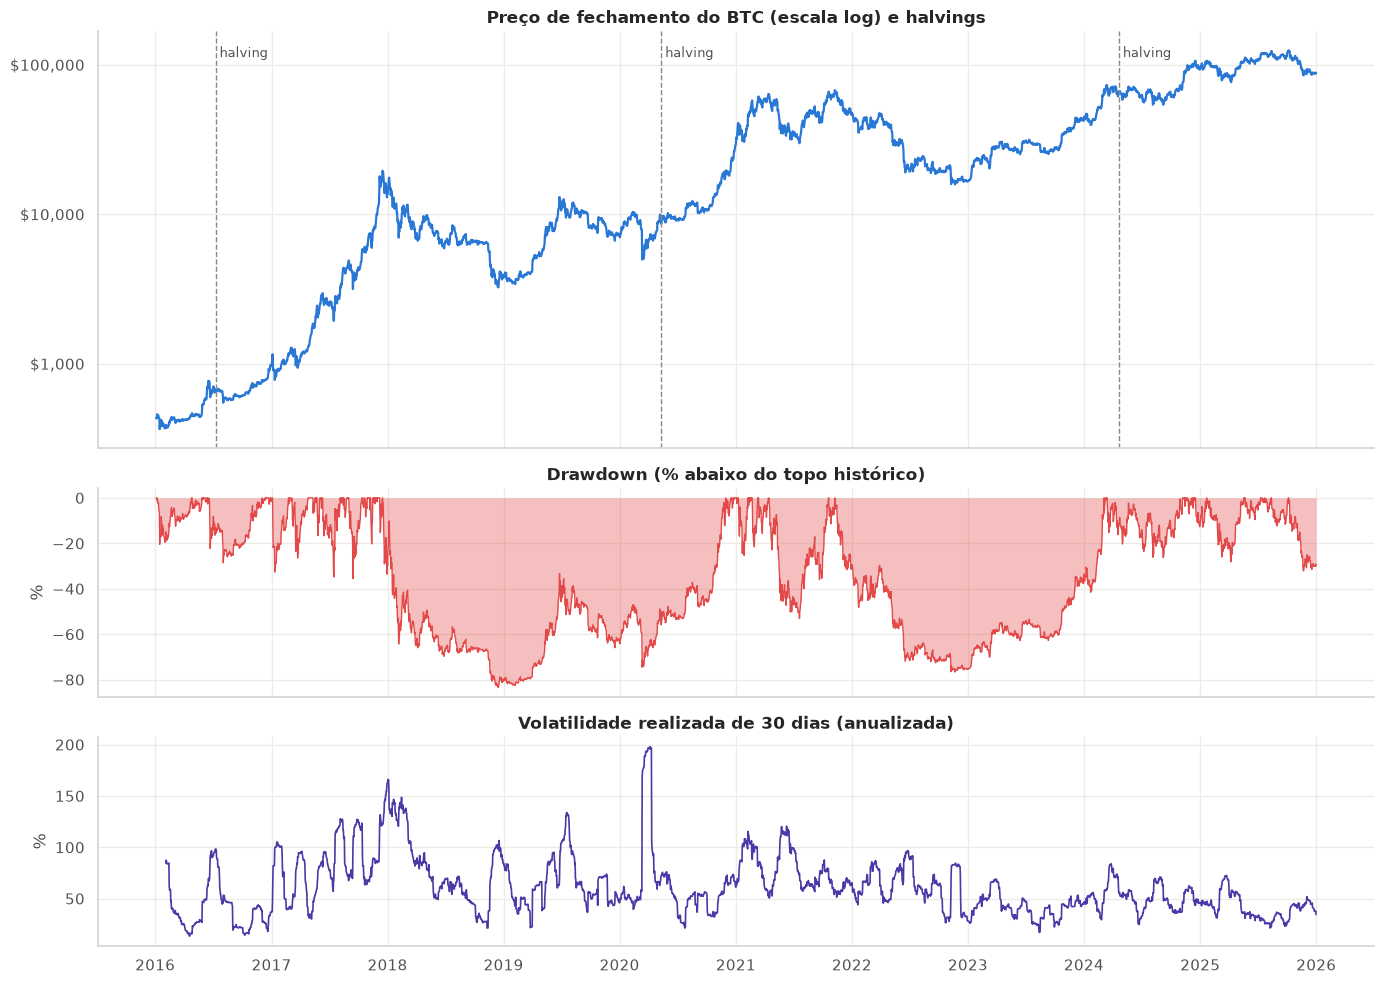

Retorno total no período: 20,105.6%
Retorno anualizado (CAGR): 70.1%
Volatilidade anualizada: 67.5%
Máximo drawdown: -83.4% em 2018-12-15


In [10]:
btc = df["BTC_Close"]
r = np.log(btc).diff().dropna()          # log-retorno diário
dd = btc / btc.cummax() - 1              # drawdown em relação ao topo histórico
vol30 = r.rolling(30).std() * np.sqrt(365)

HALVINGS = pd.to_datetime(["2016-07-09", "2020-05-11", "2024-04-20"])

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True, gridspec_kw={"height_ratios": [2, 1, 1]})

axes[0].plot(btc.index, btc, color=C[0])
axes[0].set_yscale("log")
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${v:,.0f}"))
axes[0].set_title("Preço de fechamento do BTC (escala log) e halvings")
for h in HALVINGS:
    axes[0].axvline(h, color=GRAY, ls="--", lw=1)
    axes[0].text(h, btc.max() * 0.9, " halving", color="#52514e", fontsize=9)

axes[1].fill_between(dd.index, dd * 100, 0, color=C[7], alpha=0.35, lw=0)
axes[1].plot(dd.index, dd * 100, color=C[7], lw=1)
axes[1].set_title("Drawdown (% abaixo do topo histórico)")
axes[1].set_ylabel("%")

axes[2].plot(vol30.index, vol30 * 100, color=C[6], lw=1.2)
axes[2].set_title("Volatilidade realizada de 30 dias (anualizada)")
axes[2].set_ylabel("%")
axes[2].xaxis.set_major_locator(mdates.YearLocator())
axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.show()

print(f"Retorno total no período: {btc.iloc[-1] / btc.iloc[0] - 1:,.1%}")
print(f"Retorno anualizado (CAGR): {(btc.iloc[-1] / btc.iloc[0]) ** (365 / (len(btc) - 1)) - 1:.1%}")
print(f"Volatilidade anualizada: {r.std() * np.sqrt(365):.1%}")
print(f"Máximo drawdown: {dd.min():.1%} em {dd.idxmin().date()}")

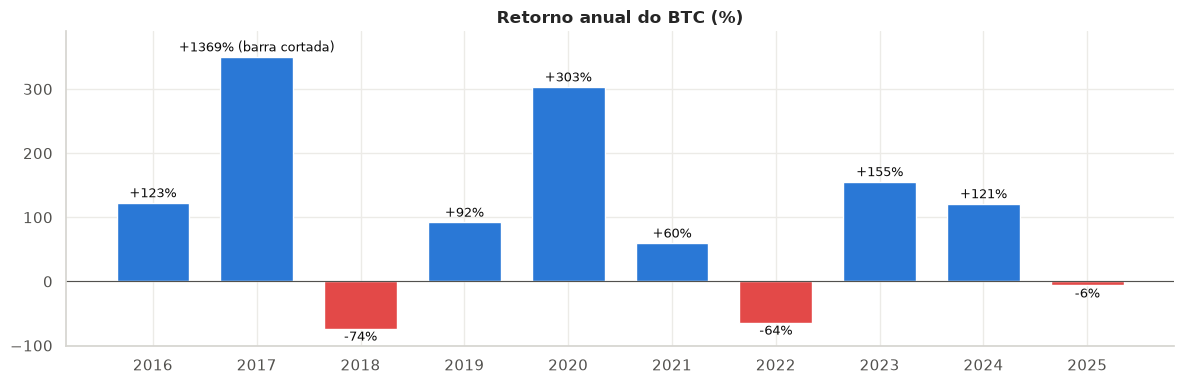

,retorno (%),volatilidade_anualizada (%),max_drawdown (%)
Date,,,
2016,122.5000,48.5000,-28.6000
2017,"1,368.9000",94.2000,-35.5000
2018,-73.6000,82.0000,-81.5000
2019,92.2000,67.5000,-49.0000
2020,303.2000,76.6000,-51.9000
2021,59.7000,80.3000,-53.1000
2022,-64.3000,64.2000,-66.9000
2023,155.4000,43.3000,-20.1000
2024,121.1000,53.1000,-26.2000


In [11]:
anual = pd.DataFrame({
    "retorno": btc.resample("YE").last().pct_change(),
    "volatilidade_anualizada": r.groupby(r.index.year).std().set_axis(btc.resample("YE").last().index) * np.sqrt(365),
    "max_drawdown": (btc.groupby(btc.index.year).apply(lambda s: (s / s.cummax() - 1).min())).set_axis(btc.resample("YE").last().index),
})
# 2016: usa o primeiro preço disponível como base
anual.iloc[0, 0] = btc[btc.index.year == 2016].iloc[-1] / btc.iloc[0] - 1
anual.index = anual.index.year

fig, ax = plt.subplots(figsize=(12, 4))
cores = [C[0] if v >= 0 else C[7] for v in anual["retorno"]]
TETO = 350  # 2017 (+1369%) é cortado para não achatar os demais anos
ax.bar(anual.index, (anual["retorno"] * 100).clip(upper=TETO), color=cores, width=0.7)
ax.axhline(0, color="#52514e", lw=0.8)
for x, v in zip(anual.index, anual["retorno"]):
    y = min(v * 100, TETO)
    rotulo = f"{v:+.0%}" + (" (barra cortada)" if v * 100 > TETO else "")
    ax.text(x, y + (4 if v >= 0 else -4), rotulo, ha="center", va="bottom" if v >= 0 else "top", fontsize=9, color="#0b0b0b")
ax.set_ylim(-100, TETO + 40)
ax.set_title("Retorno anual do BTC (%)")
ax.set_xticks(anual.index)
plt.tight_layout()
plt.show()
display((anual * 100).round(1).add_suffix(" (%)"))

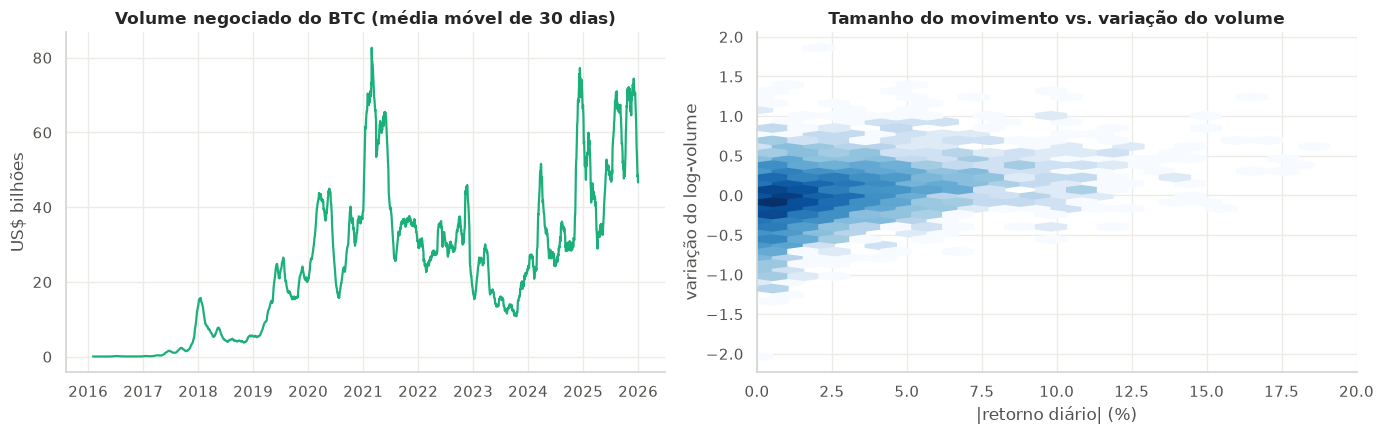

In [12]:
vol = df["BTC_Volume"]
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].plot(vol.index, vol.rolling(30).mean() / 1e9, color=C[2])
axes[0].set_title("Volume negociado do BTC (média móvel de 30 dias)")
axes[0].set_ylabel("US$ bilhões")

dlogvol = np.log(vol).diff().dropna()
axes[1].hexbin(r.abs() * 100, dlogvol.loc[r.index], gridsize=45, cmap="Blues", mincnt=1, bins="log")
axes[1].set_xlim(0, 20)
axes[1].set_xlabel("|retorno diário| (%)")
axes[1].set_ylabel("variação do log-volume")
axes[1].set_title("Tamanho do movimento vs. variação do volume")
plt.tight_layout()
plt.show()

#### H1. Os retornos diários do BTC seguem uma distribuição normal?

- **H0:** os log-retornos diários são normalmente distribuídos.
- **Testes:** Jarque-Bera (assimetria e curtose) e Kolmogorov-Smirnov contra a normal padronizada.

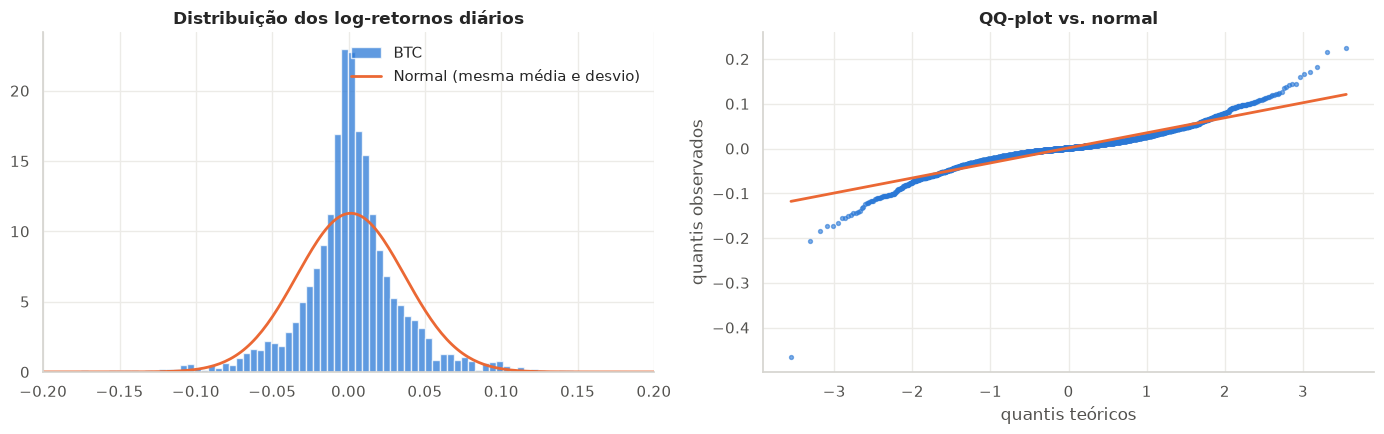

Assimetria: -0.667 | Curtose em excesso: 12.23 (normal = 0)
Dias com |retorno| > 3 desvios: 64 (esperado numa normal: 10)

Jarque-Bera
   H0: retornos normais
   p-valor = 0 -> REJEITA H0 (α = 0.05)
Kolmogorov-Smirnov
   H0: retornos normais
   p-valor = 1.323e-31 -> REJEITA H0 (α = 0.05)


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
x = np.linspace(r.min(), r.max(), 400)
axes[0].hist(r, bins=150, density=True, color=C[0], alpha=0.75, label="BTC")
axes[0].plot(x, stats.norm.pdf(x, r.mean(), r.std()), color=C[1], lw=2, label="Normal (mesma média e desvio)")
axes[0].set_xlim(-0.2, 0.2)
axes[0].set_title("Distribuição dos log-retornos diários")
axes[0].legend(frameon=False)

(osm, osr), (slope, intercept, _) = stats.probplot(r, dist="norm")
axes[1].scatter(osm, osr, s=8, color=C[0], alpha=0.6)
axes[1].plot(osm, slope * osm + intercept, color=C[1], lw=2)
axes[1].set_title("QQ-plot vs. normal")
axes[1].set_xlabel("quantis teóricos")
axes[1].set_ylabel("quantis observados")
plt.tight_layout()
plt.show()

print(f"Assimetria: {stats.skew(r):.3f} | Curtose em excesso: {stats.kurtosis(r):.2f} (normal = 0)")
z = (r - r.mean()) / r.std()
print(f"Dias com |retorno| > 3 desvios: {(z.abs() > 3).sum()} (esperado numa normal: {len(r) * 2 * stats.norm.sf(3):.0f})")
print("\nJarque-Bera"); veredito(stats.jarque_bera(r).pvalue, "retornos normais")
print("Kolmogorov-Smirnov"); veredito(stats.kstest(z, "norm").pvalue, "retornos normais")

**Conclusão H1:** normalidade é rejeitada com folga. A distribuição tem **caudas muito pesadas** (curtose em excesso ≈ 12) e leve **assimetria negativa**: quedas extremas são mais violentas que altas extremas. Houve 64 dias com movimentos maiores que 3 desvios-padrão, contra cerca de 10 esperados numa normal (aproximadamente 6 vezes mais). Por isso, medidas como VaR gaussiano subestimam o risco, e os testes seguintes são não paramétricos.

#### H2. O preço é não estacionário e o retorno é estacionário?

- **ADF:** H0 = a série tem raiz unitária (não estacionária).
- **KPSS:** H0 = a série é estacionária.

Os dois testes têm hipóteses nulas opostas, então usá-los juntos dá um diagnóstico mais confiável.

In [14]:
def teste_estacionariedade(serie, nome):
    p_adf = adfuller(serie.dropna(), autolag="AIC")[1]
    p_kpss = kpss(serie.dropna(), regression="c", nlags="auto")[1]
    return {"série": nome, "ADF p-valor": p_adf, "KPSS p-valor": p_kpss,
            "diagnóstico": "estacionária" if (p_adf < ALPHA and p_kpss >= ALPHA) else
                           "não estacionária" if (p_adf >= ALPHA and p_kpss < ALPHA) else "inconclusivo"}

display(pd.DataFrame([
    teste_estacionariedade(np.log(btc), "log(preço BTC)"),
    teste_estacionariedade(r, "log-retorno BTC"),
    teste_estacionariedade(np.log(df["NASDAQ_100"]), "log(Nasdaq 100)"),
    teste_estacionariedade(np.log(df["NASDAQ_100"]).diff(), "log-retorno Nasdaq 100"),
]).set_index("série"))
print("Obs.: o KPSS limita o p-valor ao intervalo [0,01; 0,10], então 0,01 significa '< 0,01' e 0,10 significa '> 0,10'.")

,ADF p-valor,KPSS p-valor,diagnóstico
série,,,
log(preço BTC),0.3118,0.0100,não estacionária
log-retorno BTC,0.0000,0.1000,estacionária
log(Nasdaq 100),0.8369,0.0100,não estacionária
log-retorno Nasdaq 100,0.0000,0.1000,estacionária


Obs.: o KPSS limita o p-valor ao intervalo [0,01; 0,10], então 0,01 significa '< 0,01' e 0,10 significa '> 0,10'.


**Conclusão H2:** o **nível** de preço é não estacionário (passeio aleatório) e o **retorno** é estacionário. O mesmo vale para os índices de ações. Correlações entre **níveis** de séries com tendência são em grande parte **espúrias**; por isso as relações entre variáveis são analisadas em retornos ou variações.

#### H3. Os retornos são previsíveis pelo passado? Há clusters de volatilidade?

- **Ljung-Box em $r_t$:** H0 = não há autocorrelação nos retornos (eficiência fraca).
- **Ljung-Box em $r_t^2$ e teste ARCH-LM:** H0 = não há heterocedasticidade condicional, ou seja, a volatilidade não se agrupa.

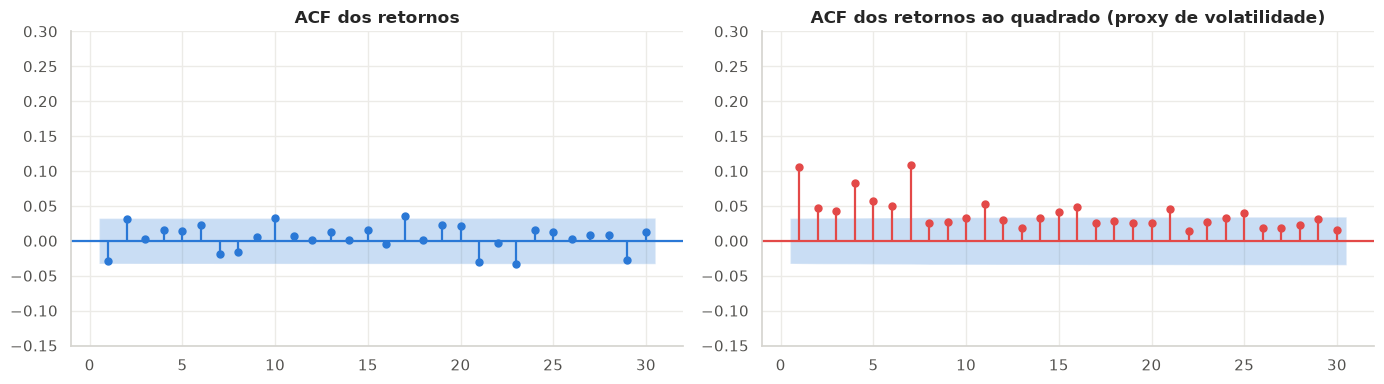

Ljung-Box (10 lags) em r
   H0: sem autocorrelação nos retornos
   p-valor = 0.08794 -> NÃO rejeita H0 (α = 0.05)
Ljung-Box (10 lags) em r²
   H0: sem autocorrelação na volatilidade
   p-valor = 8.368e-28 -> REJEITA H0 (α = 0.05)
ARCH-LM
   H0: sem efeito ARCH
   p-valor = 2.219e-19 -> REJEITA H0 (α = 0.05)


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(r, lags=30, ax=axes[0], zero=False, color=C[0], vlines_kwargs={"colors": C[0]})
axes[0].set_title("ACF dos retornos")
plot_acf(r ** 2, lags=30, ax=axes[1], zero=False, color=C[7], vlines_kwargs={"colors": C[7]})
axes[1].set_title("ACF dos retornos ao quadrado (proxy de volatilidade)")
for ax in axes:
    ax.set_ylim(-0.15, 0.3)
plt.tight_layout()
plt.show()

lb_r = acorr_ljungbox(r, lags=[10])["lb_pvalue"].iloc[0]
lb_r2 = acorr_ljungbox(r ** 2, lags=[10])["lb_pvalue"].iloc[0]
print("Ljung-Box (10 lags) em r"); veredito(lb_r, "sem autocorrelação nos retornos")
print("Ljung-Box (10 lags) em r²"); veredito(lb_r2, "sem autocorrelação na volatilidade")
print("ARCH-LM"); veredito(het_arch(r)[1], "sem efeito ARCH")

**Conclusão H3:** os **retornos** praticamente não têm memória linear (não se rejeita H0 a 5%), o que é compatível com eficiência fraca: o retorno de ontem não prevê o de hoje. Já os **retornos ao quadrado** são fortemente autocorrelacionados e o teste ARCH é significativo: há **clusters de volatilidade**, em que dias turbulentos vêm seguidos de dias turbulentos. Para modelagem, a **volatilidade** é bem mais previsível que a **direção** do preço (modelos GARCH são candidatos naturais).

#### H4. Movimentos maiores de preço vêm acompanhados de mais volume?

- **H0:** não há correlação monotônica entre |retorno| e a variação do log-volume (Spearman ρ = 0).

In [16]:
rho, p = stats.spearmanr(r.abs(), dlogvol.loc[r.index])
print(f"Spearman ρ(|retorno|, Δlog volume) = {rho:.3f}")
veredito(p, "ρ = 0")

quintis = pd.qcut(r.abs(), 5, labels=["Q1 (menores)", "Q2", "Q3", "Q4", "Q5 (maiores)"])
display(dlogvol.loc[r.index].groupby(quintis).agg(["mean", "median"]).rename(columns={"mean": "Δlog vol médio", "median": "Δlog vol mediano"}))

Spearman ρ(|retorno|, Δlog volume) = 0.343
   H0: ρ = 0
   p-valor = 1.925e-101 -> REJEITA H0 (α = 0.05)


,Δlog vol médio,Δlog vol mediano
BTC_Close,,
Q1 (menores),-0.1277,-0.0935
Q2,-0.0697,-0.0616
Q3,-0.0282,-0.0286
Q4,0.0472,0.0234
Q5 (maiores),0.1877,0.1594


**Conclusão H4:** há uma relação positiva e significativa, de intensidade moderada (ρ ≈ 0,34): dias de movimentos maiores, em qualquer direção, concentram aumento de volume. O volume carrega informação sobre a **intensidade** do mercado, não sobre a direção.

#### H5. Existe sazonalidade (dia da semana ou mês) nos retornos? A volatilidade é menor nos fins de semana?

- **Kruskal-Wallis:** H0 = a distribuição dos retornos é a mesma em todos os dias da semana (e em todos os meses).
- **Levene:** H0 = a variância dos retornos no fim de semana é igual à dos dias úteis.

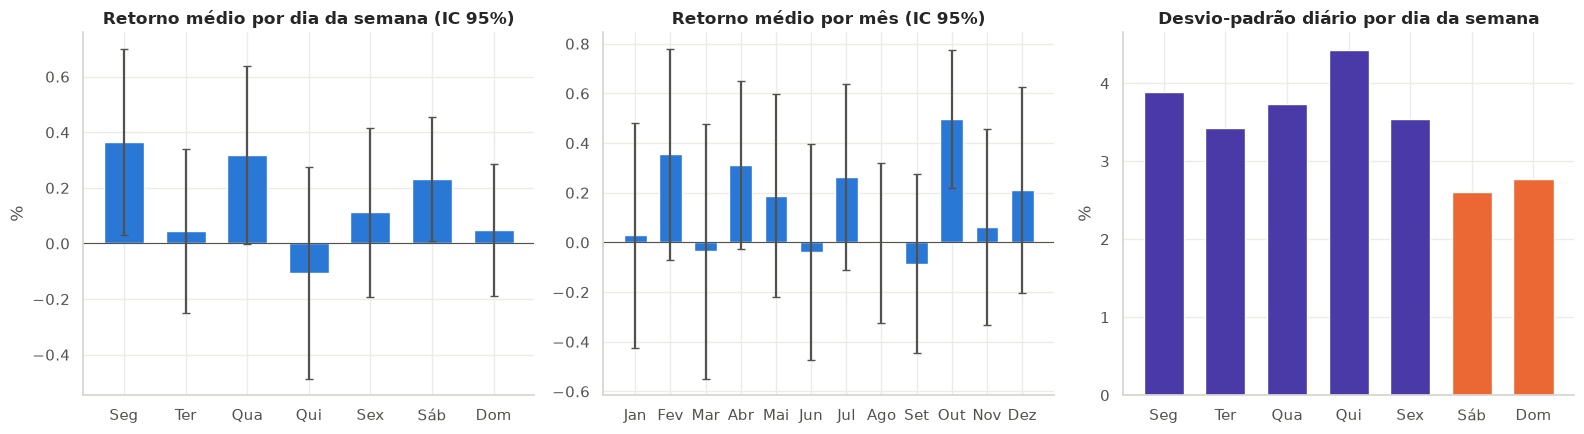

Kruskal-Wallis: dia da semana
   H0: mesma distribuição em todos os dias
   p-valor = 0.4872 -> NÃO rejeita H0 (α = 0.05)
Kruskal-Wallis: mês
   H0: mesma distribuição em todos os meses
   p-valor = 0.8919 -> NÃO rejeita H0 (α = 0.05)
Levene: fim de semana (σ = 2.69%) vs. dias úteis (σ = 3.82%)
   H0: variâncias iguais
   p-valor = 8.678e-18 -> REJEITA H0 (α = 0.05)


In [17]:
dias = ["Seg", "Ter", "Qua", "Qui", "Sex", "Sáb", "Dom"]
meses = ["Jan", "Fev", "Mar", "Abr", "Mai", "Jun", "Jul", "Ago", "Set", "Out", "Nov", "Dez"]
tab = pd.DataFrame({"r": r * 100, "dia": pd.Categorical([dias[d] for d in r.index.dayofweek], dias),
                    "mes": pd.Categorical([meses[m - 1] for m in r.index.month], meses)})

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
por_dia = tab.groupby("dia", observed=True)["r"]
axes[0].bar(dias, por_dia.mean(), color=C[0], width=0.65)
axes[0].errorbar(dias, por_dia.mean(), yerr=1.96 * por_dia.sem(), fmt="none", ecolor="#52514e", capsize=3)
axes[0].axhline(0, color="#52514e", lw=0.8)
axes[0].set_title("Retorno médio por dia da semana (IC 95%)")
axes[0].set_ylabel("%")

por_mes = tab.groupby("mes", observed=True)["r"]
axes[1].bar(meses, por_mes.mean(), color=C[0], width=0.65)
axes[1].errorbar(meses, por_mes.mean(), yerr=1.96 * por_mes.sem(), fmt="none", ecolor="#52514e", capsize=3)
axes[1].axhline(0, color="#52514e", lw=0.8)
axes[1].set_title("Retorno médio por mês (IC 95%)")

desvio = por_dia.std()
axes[2].bar(dias, desvio, color=[C[6]] * 5 + [C[1]] * 2, width=0.65)
axes[2].set_title("Desvio-padrão diário por dia da semana")
axes[2].set_ylabel("%")
plt.tight_layout()
plt.show()

print("Kruskal-Wallis: dia da semana")
veredito(stats.kruskal(*[g for _, g in por_dia]).pvalue, "mesma distribuição em todos os dias")
print("Kruskal-Wallis: mês")
veredito(stats.kruskal(*[g for _, g in por_mes]).pvalue, "mesma distribuição em todos os meses")
fds = r.index.dayofweek >= 5
print(f"Levene: fim de semana (σ = {r[fds].std():.2%}) vs. dias úteis (σ = {r[~fds].std():.2%})")
veredito(stats.levene(r[fds], r[~fds]).pvalue, "variâncias iguais")

**Conclusão H5:** não há evidência de sazonalidade no **retorno médio**, nem por dia da semana nem por mês. As diferenças visuais ficam dentro dos intervalos de confiança. Por outro lado, a **volatilidade é significativamente menor nos fins de semana**, quando os mercados tradicionais (e o fluxo institucional) estão fechados. Isso sugere que o BTC está integrado ao calendário do sistema financeiro tradicional.

#### Halvings: o que aconteceu com o preço depois de cada um

Com apenas 3 eventos não é possível fazer um teste estatístico com poder algum, então esta parte é **apenas descritiva**.

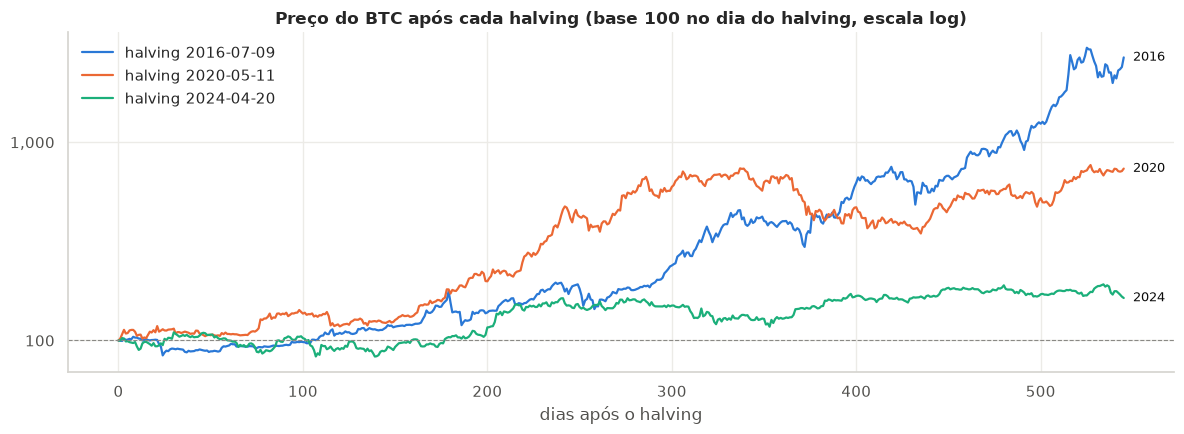

,+90d (%),+180d (%),+365d (%),+540d (%)
2016-07-09,-5.0000,56.0000,287.0000,"2,075.0000"
2020-05-11,36.0000,72.0000,559.0000,635.0000
2024-04-20,3.0000,4.0000,31.0000,77.0000


In [18]:
horizontes = [90, 180, 365, 540]
linhas = {}
fig, ax = plt.subplots(figsize=(12, 4.5))
for i, h in enumerate(HALVINGS):
    p0 = btc.asof(h)
    janela = btc[h: h + pd.Timedelta(days=545)] / p0 * 100
    ax.plot((janela.index - h).days, janela.values, color=C[i], label=f"halving {h.date()}")
    ax.text((janela.index[-1] - h).days + 5, janela.iloc[-1], str(h.year), color="#0b0b0b", fontsize=9, va="center")
    linhas[str(h.date())] = {f"+{d}d": btc.asof(h + pd.Timedelta(days=d)) / p0 - 1 for d in horizontes}
ax.axhline(100, color=GRAY, lw=0.8, ls="--")
ax.set_yscale("log")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax.set_title("Preço do BTC após cada halving (base 100 no dia do halving, escala log)")
ax.set_xlabel("dias após o halving")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()
display((pd.DataFrame(linhas).T * 100).round(0).add_suffix(" (%)"))

**Leitura:** os três halvings foram seguidos de alta em 12 a 18 meses, mas a **magnitude diminui a cada ciclo**, o que é coerente com um mercado maior e mais maduro. Com n = 3 e muitos fatores simultâneos (liquidez global, ETFs), isso não é evidência causal.

### 3. BTC vs. mercados globais (frequência diária, somente dias úteis)

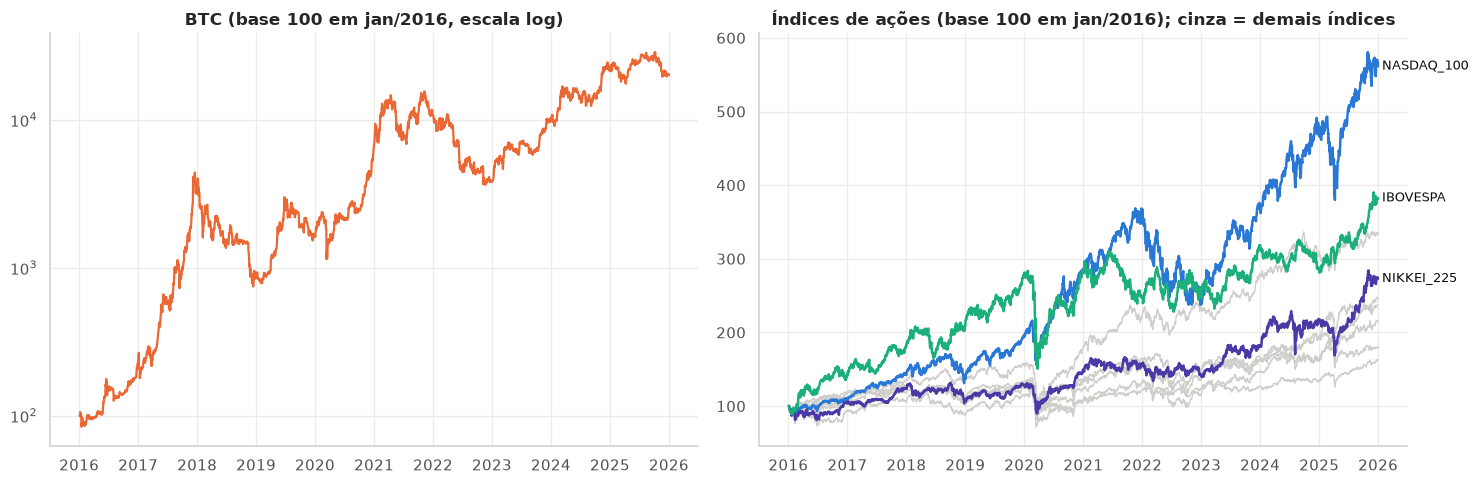

Multiplicador no período (fim / início):


,BTC_Close,NASDAQ_100,IBOVESPA,NIFTY_50,NIKKEI_225,SP_TSX,DAX,FTSE_MIB,CAC_40,FTSE_100
x,202.0600,5.6100,3.8200,3.3500,2.7300,2.4500,2.3800,2.1700,1.8000,1.6300


In [19]:
uteis = df[df.index.dayofweek < 5]
indices = grupos["Índices"]
cambio = grupos["Câmbio"]

base = uteis[["BTC_Close"] + indices]
norm = base / base.iloc[0] * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(norm.index, norm["BTC_Close"], color=C[1])
axes[0].set_yscale("log")
axes[0].set_title("BTC (base 100 em jan/2016, escala log)")
destaque = {"NASDAQ_100": C[0], "IBOVESPA": C[2], "NIKKEI_225": C[6]}
for col in indices:
    cor, lw = destaque.get(col, "#cfceca"), (1.8 if col in destaque else 1)
    axes[1].plot(norm.index, norm[col], color=cor, lw=lw, zorder=3 if col in destaque else 1)
for col, cor in destaque.items():
    axes[1].text(norm.index[-1], norm[col].iloc[-1], f" {col}", color="#0b0b0b", fontsize=9, va="center")
axes[1].set_title("Índices de ações (base 100 em jan/2016); cinza = demais índices")
plt.tight_layout()
plt.show()

print("Multiplicador no período (fim / início):")
display((base.iloc[-1] / base.iloc[0]).sort_values(ascending=False).to_frame("x").T.round(2))

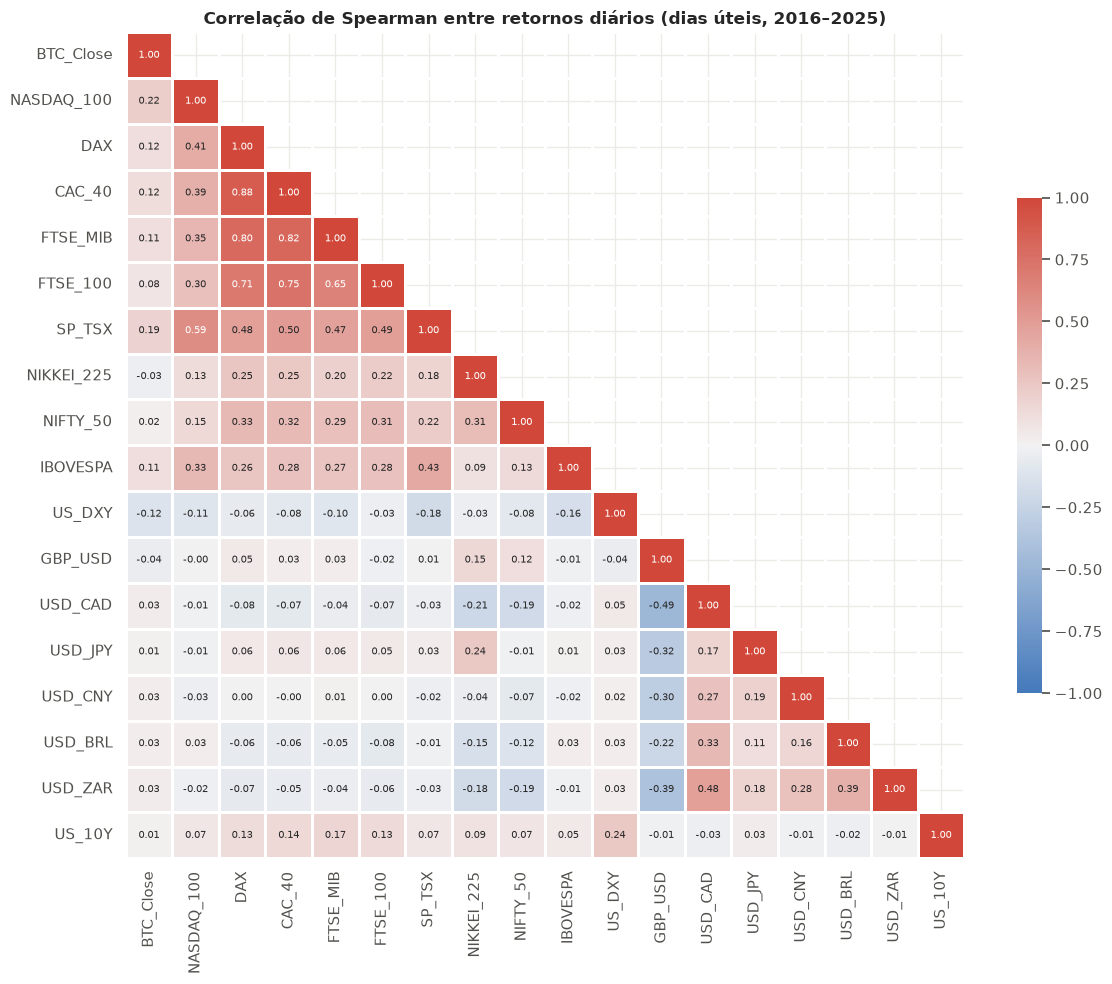

,rho,p_valor,significativo
US_DXY,-0.1195,0.0000,True
GBP_USD,-0.0413,0.0350,True
NIKKEI_225,-0.0294,0.1340,False
US_10Y,0.0090,0.6473,False
USD_JPY,0.0092,0.6393,False
NIFTY_50,0.0216,0.2710,False
USD_CNY,0.0298,0.1277,False
USD_BRL,0.0311,0.1126,False
USD_CAD,0.0313,0.1103,False
USD_ZAR,0.0321,0.1016,False


In [20]:
ret_d = np.log(uteis[["BTC_Close"] + indices + cambio]).diff()
ret_d["US_10Y"] = uteis["US_10Y"].diff()   # taxa: usa variação absoluta, não log
ret_d = ret_d.dropna()

corr = ret_d.corr(method="spearman")
fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, cmap=CMAP_DIV, vmin=-1, vmax=1, center=0, annot=True, fmt=".2f",
            annot_kws={"size": 7}, linewidths=1, linecolor="white", cbar_kws={"shrink": 0.6}, ax=ax)
ax.set_title("Correlação de Spearman entre retornos diários (dias úteis, 2016–2025)")
plt.tight_layout()
plt.show()

corr_btc = pd.DataFrame({
    "rho": corr["BTC_Close"].drop("BTC_Close"),
    "p_valor": [stats.spearmanr(ret_d["BTC_Close"], ret_d[c]).pvalue for c in corr.columns.drop("BTC_Close")],
}).sort_values("rho")
corr_btc["significativo"] = corr_btc["p_valor"] < ALPHA
display(corr_btc)

**Leitura:** considerando o período inteiro, o BTC tem correlação **fraca** com todos os ativos. As maiores são com **Nasdaq 100** (ρ ≈ 0,22) e S&P/TSX (positivas, perfil de ativo de risco) e com o **DXY** (negativa: dólar forte, BTC fraco). Já entre os índices de ações as correlações são bem mais altas, o que mostra que o BTC ainda funciona como um fator de risco à parte. A média de 10 anos, porém, esconde uma mudança de regime, testada a seguir.

#### H6. A correlação do BTC com as ações de tecnologia aumentou a partir de 2020?

- **H0:** a correlação de Pearson entre os retornos do BTC e da Nasdaq 100 é a mesma antes (2016–2019) e depois (2020–2025) de jan/2020.
- **Teste:** comparação de duas correlações independentes pela transformação z de Fisher.

,corr 2016-19,corr 2020-25,z,p_valor,rejeita H0
ativo,,,,,
NASDAQ_100,0.0241,0.3946,9.8188,0.0000,True
US_DXY,-0.0240,-0.1393,-2.9034,0.0037,True
IBOVESPA,0.0397,0.2843,6.3091,0.0000,True
DAX,0.0001,0.2747,7.0390,0.0000,True


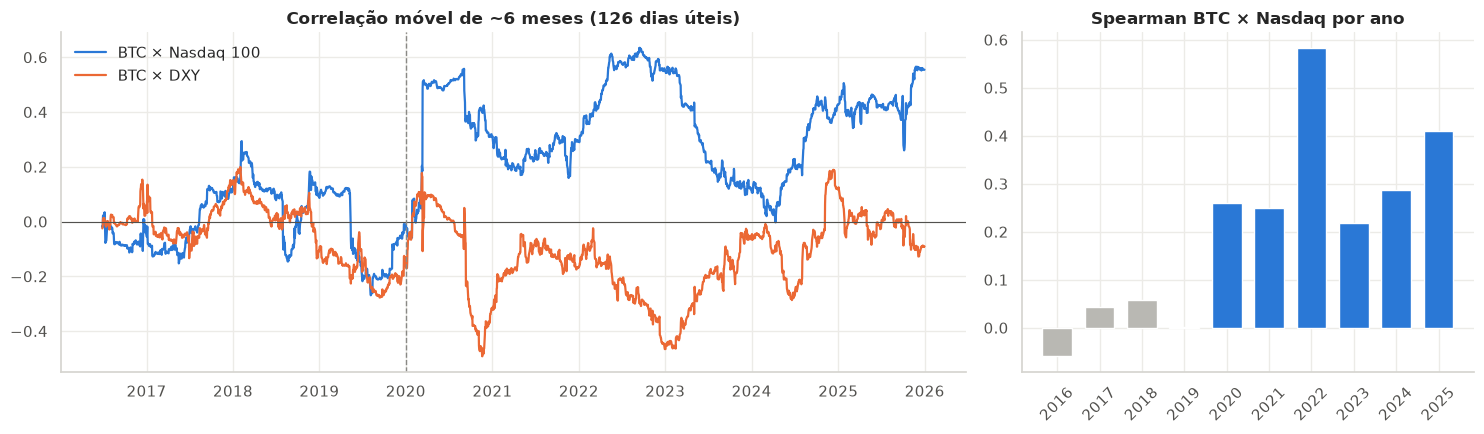

In [21]:
def fisher_z(r1, n1, r2, n2):
    z = (np.arctanh(r2) - np.arctanh(r1)) / np.sqrt(1 / (n1 - 3) + 1 / (n2 - 3))
    return z, 2 * stats.norm.sf(abs(z))

pre, pos = ret_d[ret_d.index < "2020-01-01"], ret_d[ret_d.index >= "2020-01-01"]
linhas = []
for ativo in ["NASDAQ_100", "US_DXY", "IBOVESPA", "DAX"]:
    r1, r2 = pre["BTC_Close"].corr(pre[ativo]), pos["BTC_Close"].corr(pos[ativo])
    zst, p = fisher_z(r1, len(pre), r2, len(pos))
    linhas.append({"ativo": ativo, "corr 2016-19": r1, "corr 2020-25": r2, "z": zst, "p_valor": p, "rejeita H0": p < ALPHA})
display(pd.DataFrame(linhas).set_index("ativo"))

roll = pd.DataFrame({a: ret_d["BTC_Close"].rolling(126).corr(ret_d[a]) for a in ["NASDAQ_100", "US_DXY"]})
anual_c = ret_d.groupby(ret_d.index.year).apply(lambda g: g["BTC_Close"].corr(g["NASDAQ_100"], method="spearman"))

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5), gridspec_kw={"width_ratios": [2, 1]})
axes[0].plot(roll.index, roll["NASDAQ_100"], color=C[0], label="BTC × Nasdaq 100")
axes[0].plot(roll.index, roll["US_DXY"], color=C[1], label="BTC × DXY")
axes[0].axhline(0, color="#52514e", lw=0.8)
axes[0].axvline(pd.Timestamp("2020-01-01"), color=GRAY, ls="--", lw=1)
axes[0].set_title("Correlação móvel de ~6 meses (126 dias úteis)")
axes[0].legend(frameon=False, loc="upper left")
axes[1].bar(anual_c.index, anual_c.values, color=[C[0] if y >= 2020 else "#b9b8b3" for y in anual_c.index], width=0.7)
axes[1].set_title("Spearman BTC × Nasdaq por ano")
axes[1].set_xticks(anual_c.index)
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

**Conclusão H6:** rejeita-se H0. A correlação BTC × Nasdaq praticamente **não existia antes de 2020** (≈ 0,02) e passou para ≈ 0,4 depois, com pico em **2022** (aperto monetário do Fed). A relação negativa com o DXY também ficou mais forte, e o mesmo aumento aparece com DAX e Ibovespa: é uma integração com os mercados de risco em geral, e não só com tecnologia. A partir da pandemia, a entrada de investidores institucionais fez o BTC se comportar como um **ativo de risco ligado à liquidez**, não como um ativo descorrelacionado. Na prática, um modelo treinado com dados de 2016–2019 não deve ser aplicado sem cuidado ao período pós-2020.

#### H7. Os mercados tradicionais antecedem o BTC (causalidade de Granger)?

- **H0:** os retornos defasados do ativo X **não** melhoram a previsão do retorno do BTC, além do que o próprio passado do BTC já explica (e vice-versa).
- Aplicado ao período pós-2020, em que existe correlação contemporânea (H6), com 1 a 5 defasagens (dias úteis).

Granger mede **precedência preditiva**, não causalidade no sentido econômico.

In [22]:
def granger_p(dados, y, x, maxlag):
    """Menor p-valor (teste F) entre as defasagens 1..maxlag para 'x Granger-causa y'."""
    res = grangercausalitytests(dados[[y, x]].dropna(), maxlag=maxlag)
    return {f"lag {l}": res[l][0]["ssr_ftest"][1] for l in res}

granger_d = {}
for ativo in ["NASDAQ_100", "US_DXY", "US_10Y", "IBOVESPA", "NIKKEI_225"]:
    granger_d[f"{ativo} → BTC"] = granger_p(pos, "BTC_Close", ativo, 5)
    granger_d[f"BTC → {ativo}"] = granger_p(pos, ativo, "BTC_Close", 5)
granger_d = pd.DataFrame(granger_d).T
display(granger_d.round(3))
print("Pares com p < 0,05 em alguma defasagem:", list(granger_d.index[(granger_d < ALPHA).any(axis=1)]))

,lag 1,lag 2,lag 3,lag 4,lag 5
NASDAQ_100 → BTC,0.2260,0.4790,0.5010,0.6030,0.2370
BTC → NASDAQ_100,0.4420,0.1200,0.2190,0.3520,0.4380
US_DXY → BTC,0.9920,0.6670,0.0330,0.0480,0.0470
BTC → US_DXY,0.0210,0.0070,0.0040,0.0050,0.0070
US_10Y → BTC,0.7140,0.2730,0.4510,0.5580,0.6340
BTC → US_10Y,0.6750,0.0210,0.0220,0.0420,0.0230
IBOVESPA → BTC,0.1060,0.2980,0.2940,0.2400,0.2040
BTC → IBOVESPA,0.0690,0.0010,0.0020,0.0030,0.0030
NIKKEI_225 → BTC,0.3480,0.6620,0.5230,0.5990,0.6470
BTC → NIKKEI_225,0.0000,0.0000,0.0000,0.0000,0.0000


Pares com p < 0,05 em alguma defasagem: ['US_DXY → BTC', 'BTC → US_DXY', 'BTC → US_10Y', 'BTC → IBOVESPA', 'BTC → NIKKEI_225']


**Conclusão H7:** o resultado vai no sentido **contrário** ao esperado. Os mercados tradicionais **não** antecedem o BTC: Nasdaq, 10Y, Ibovespa e Nikkei não são significativos, e o DXY só é marginal (p ≈ 0,03–0,05 nas defasagens 3 a 5). Já o **BTC "antecede" Nikkei, Ibovespa, DXY e US_10Y**, com destaque para o Nikkei (p < 0,001 em todas as defasagens).

Essa precedência se explica por **fuso horário e calendário**, e não por influência econômica. O BTC é negociado 24h e fecha o dia à meia-noite UTC, então o retorno do BTC em *t−1* já incorpora a sessão americana de *t−1*, que o Nikkei (fecha às 06h UTC) e outras praças só refletem em *t*. Na prática, o BTC funciona como um **termômetro de risco global** que chega antes do fechamento desses mercados. Para modelos de previsão, isso mostra que é preciso **alinhar os horários de fechamento** antes de usar features defasadas, para não vazar informação.

### 4. BTC vs. macroeconomia (frequência mensal)

Juros e inflação são mensais, então os dados são agregados pelo **último valor de cada mês**. Assim, cada observação é um ponto novo de informação (n ≈ 120 meses).

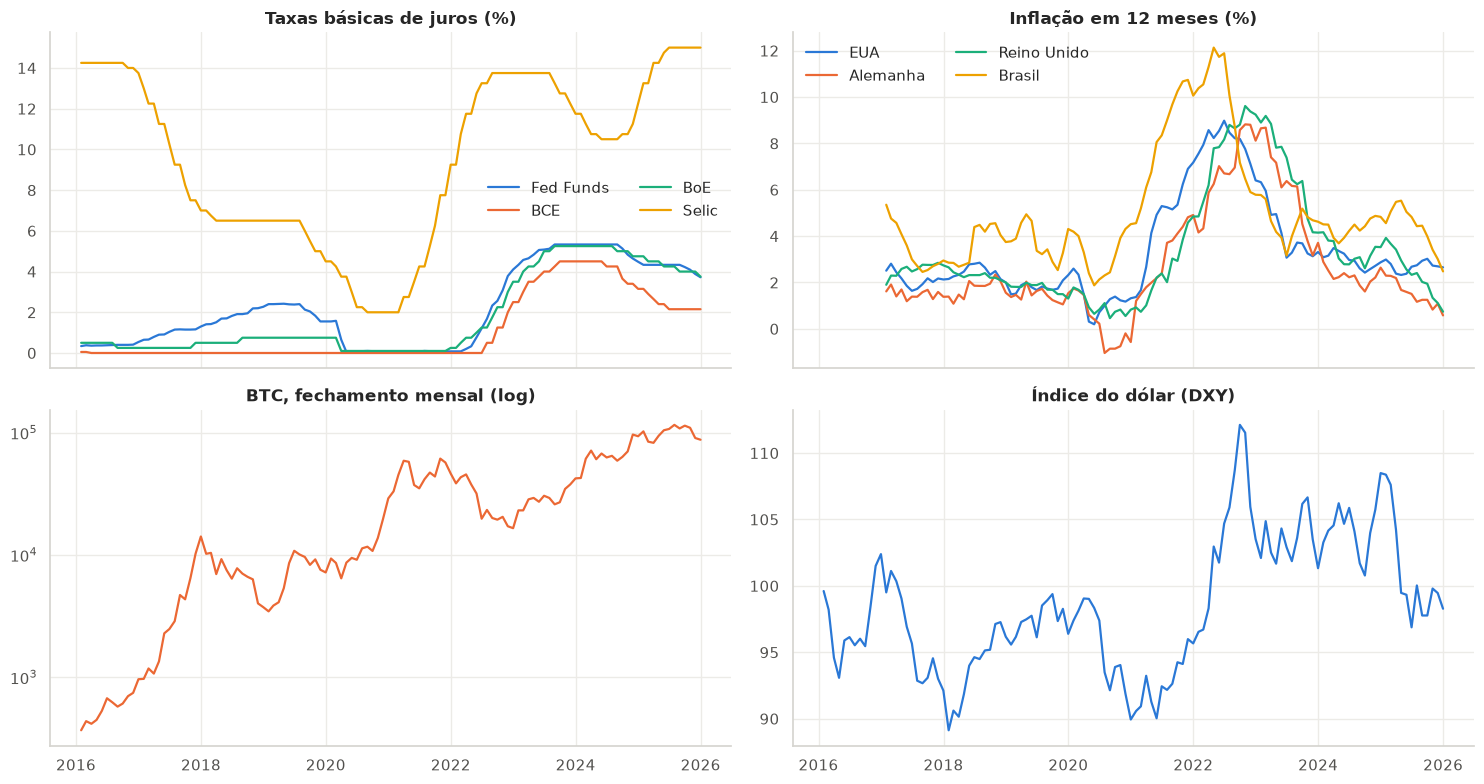

In [23]:
m = df.resample("ME").last()

fig, axes = plt.subplots(2, 2, figsize=(15, 8), sharex=True)
juros_plot = {"US_FEDFUNDS": "Fed Funds", "ECB_MAIN_REFINANCING": "BCE", "UK_POLICY_RATE": "BoE", "BRAZIL_SELIC": "Selic"}
for i, (col, nome) in enumerate(juros_plot.items()):
    axes[0, 0].plot(m.index, m[col], color=C[i], label=nome)
axes[0, 0].set_title("Taxas básicas de juros (%)")
axes[0, 0].legend(frameon=False, ncol=2)

cpi_yoy = (m[grupos["Inflação"]].pct_change(12) * 100)
for i, (col, nome) in enumerate({"US_CPI": "EUA", "GERMANY_CPI": "Alemanha", "UK_CPI": "Reino Unido", "BRAZIL_CPI": "Brasil"}.items()):
    axes[0, 1].plot(cpi_yoy.index, cpi_yoy[col], color=C[i], label=nome)
axes[0, 1].set_title("Inflação em 12 meses (%)")
axes[0, 1].legend(frameon=False, ncol=2)

axes[1, 0].plot(m.index, m["BTC_Close"], color=C[1])
axes[1, 0].set_yscale("log")
axes[1, 0].set_title("BTC, fechamento mensal (log)")
for ax in axes[1, 0], axes[1, 1]:
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

axes[1, 1].plot(m.index, m["US_DXY"], color=C[0])
axes[1, 1].set_title("Índice do dólar (DXY)")
plt.tight_layout()
plt.show()

#### Armadilha: correlação em nível vs. em variação

Antes de testar as relações macro, vale mostrar por que correlações em **nível** enganam (consequência de H2).

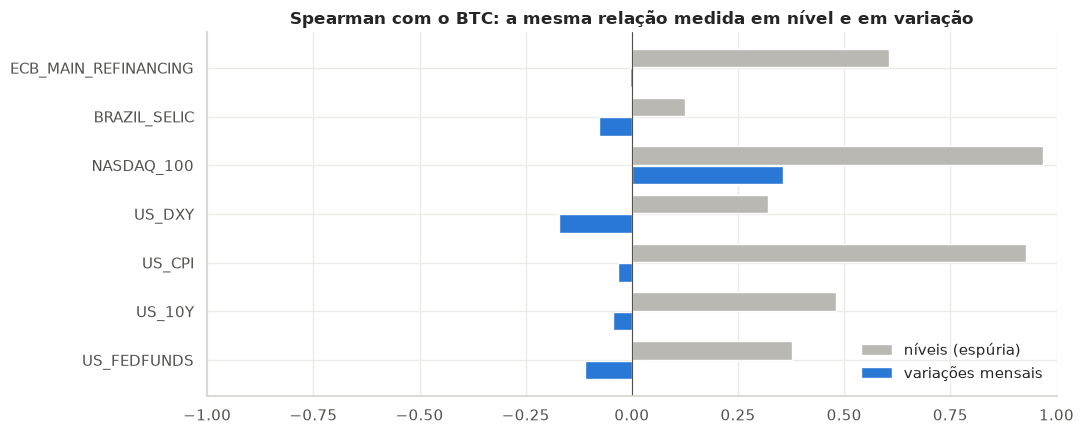

,em nível,em variação
US_FEDFUNDS,0.3762,-0.1110
US_10Y,0.4802,-0.0433
US_CPI,0.9278,-0.0333
US_DXY,0.3204,-0.1713
NASDAQ_100,0.9675,0.3561
BRAZIL_SELIC,0.1242,-0.0783
ECB_MAIN_REFINANCING,0.6066,-0.0036


In [24]:
vars_macro = ["US_FEDFUNDS", "US_10Y", "US_CPI", "US_DXY", "NASDAQ_100", "BRAZIL_SELIC", "ECB_MAIN_REFINANCING"]

nivel = m[["BTC_Close"] + vars_macro].corr(method="spearman")["BTC_Close"].drop("BTC_Close")

mr = pd.DataFrame({"BTC": np.log(m["BTC_Close"]).diff()})
for c in ["US_FEDFUNDS", "US_10Y", "BRAZIL_SELIC", "ECB_MAIN_REFINANCING", "UK_POLICY_RATE"]:
    mr[c] = m[c].diff()                         # juros: variação em p.p.
for c in ["US_CPI", "US_DXY", "NASDAQ_100", "GERMANY_CPI", "UK_CPI", "BRAZIL_CPI"]:
    mr[c] = np.log(m[c]).diff()                  # níveis de preço: variação %
mr["US_CPI_YOY"] = np.log(m["US_CPI"]).diff(12)  # inflação acumulada em 12 meses
mr = mr.dropna()

variacao = mr.corr(method="spearman")["BTC"].reindex(vars_macro)
comp = pd.DataFrame({"em nível": nivel, "em variação": variacao})

fig, ax = plt.subplots(figsize=(11, 4.5))
y = np.arange(len(comp))
ax.barh(y + 0.2, comp["em nível"], height=0.38, color="#b9b8b3", label="níveis (espúria)")
ax.barh(y - 0.2, comp["em variação"], height=0.38, color=C[0], label="variações mensais")
ax.set_yticks(y, comp.index)
ax.axvline(0, color="#52514e", lw=0.8)
ax.set_xlim(-1, 1)
ax.set_title("Spearman com o BTC: a mesma relação medida em nível e em variação")
ax.legend(frameon=False, loc="lower right")
plt.tight_layout()
plt.show()
display(comp)

**Leitura:** em nível, o BTC parece ter correlação de quase 0,93 com o CPI americano e positiva com os juros do Fed, mas isso ocorre só porque **todas essas séries sobem com o tempo**. Em variações mensais, a maior parte das relações desaparece. Somente a correlação com a Nasdaq é robusta.

#### H8. Choques macro mensais se relacionam com o retorno mensal do BTC?

- **H0 (para cada variável):** ρ de Spearman entre o retorno mensal do BTC e a variação mensal da variável é 0.
- Com vários testes simultâneos, também reporto o p-valor ajustado por **Holm-Bonferroni**.

n = 108 meses


,rho,p_valor,p_holm,significativo (Holm)
variável,,,,
NASDAQ_100,0.3561,0.0002,0.0019,True
US_CPI_YOY,-0.2367,0.0136,0.1500,False
US_DXY,-0.1713,0.0763,0.7634,False
US_FEDFUNDS,-0.1110,0.2528,1.0000,False
UK_POLICY_RATE,-0.0794,0.4143,1.0000,False
BRAZIL_SELIC,-0.0783,0.4207,1.0000,False
BRAZIL_CPI,0.0724,0.4563,1.0000,False
GERMANY_CPI,0.0703,0.4699,1.0000,False
UK_CPI,-0.0500,0.6071,1.0000,False


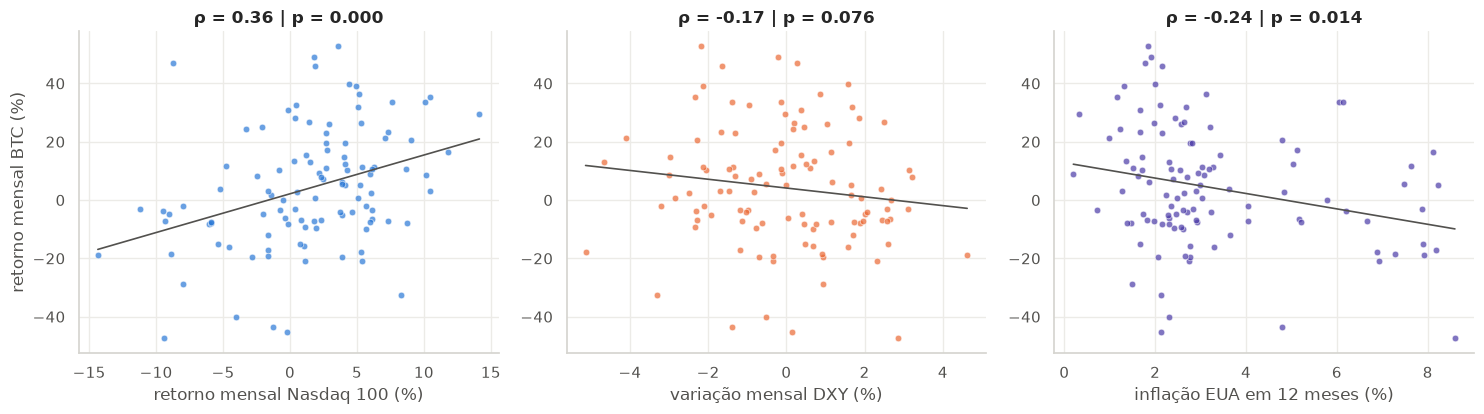

In [25]:
from statsmodels.stats.multitest import multipletests

res = []
for c in mr.columns.drop("BTC"):
    rho, p = stats.spearmanr(mr["BTC"], mr[c])
    res.append({"variável": c, "rho": rho, "p_valor": p})
res = pd.DataFrame(res).set_index("variável").sort_values("p_valor")
res["p_holm"] = multipletests(res["p_valor"], method="holm")[1]
res["significativo (Holm)"] = res["p_holm"] < ALPHA
print(f"n = {len(mr)} meses")
display(res)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))
for ax, (c, nome, cor) in zip(axes, [("NASDAQ_100", "retorno mensal Nasdaq 100", C[0]),
                                     ("US_DXY", "variação mensal DXY", C[1]),
                                     ("US_CPI_YOY", "inflação EUA em 12 meses", C[6])]):
    ax.scatter(mr[c] * 100, mr["BTC"] * 100, s=22, color=cor, alpha=0.7, edgecolor="white", lw=0.5)
    b, a = np.polyfit(mr[c] * 100, mr["BTC"] * 100, 1)
    xs = np.linspace(mr[c].min() * 100, mr[c].max() * 100, 50)
    ax.plot(xs, a + b * xs, color="#52514e", lw=1.2)
    ax.set_xlabel(f"{nome} (%)")
    ax.set_title(f"ρ = {res.loc[c, 'rho']:.2f} | p = {res.loc[c, 'p_valor']:.3f}")
axes[0].set_ylabel("retorno mensal BTC (%)")
plt.tight_layout()
plt.show()

**Conclusão H8:** em frequência mensal, **nenhuma variação de juros** (Fed, 10Y, BCE, BoE, Selic) **nem de CPI mensal** tem correlação significativa com o retorno do BTC. A única relação que resiste à correção para múltiplos testes é com a **Nasdaq 100**. A **inflação americana acumulada em 12 meses** aparece com correlação negativa (inflação alta, retornos menores do BTC, como em 2022), mas não resiste à correção de Holm e deve ser tratada como indício. Os dados não sustentam a narrativa do BTC como proteção contra inflação.

#### H9. O retorno do BTC difere entre regimes de política monetária do Fed?

Regime definido pela variação da Fed Funds nos **3 meses anteriores**: *alta* (> +0,10 p.p.), *corte* (< −0,10 p.p.) ou *estável*.

- **H0:** a distribuição do retorno mensal do BTC é a mesma nos três regimes (Kruskal-Wallis).

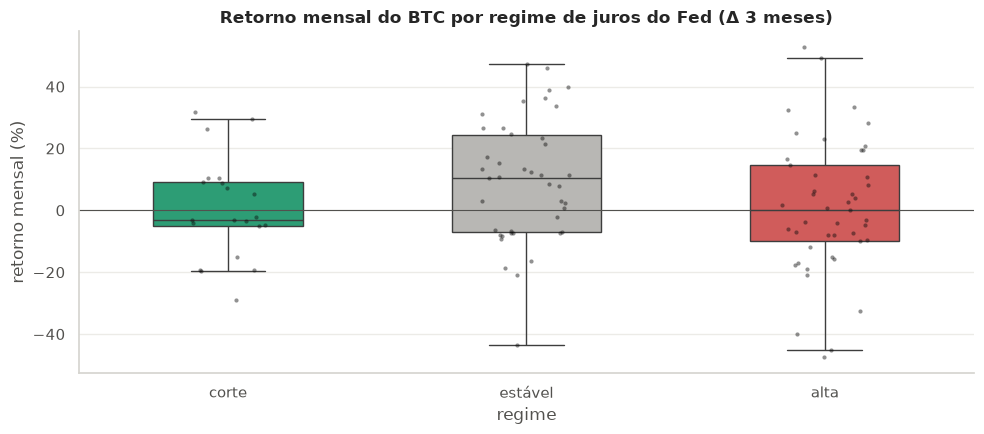

,count,mean,median,std
regime,,,,
corte,21,0.5183,-3.1811,16.2928
estável,42,9.5918,10.6054,19.9983
alta,45,0.8250,0.0349,21.8082


   H0: mesma distribuição nos 3 regimes
   p-valor = 0.08518 -> NÃO rejeita H0 (α = 0.05)


In [26]:
delta_fed = m["US_FEDFUNDS"].diff(3)
regime = pd.cut(delta_fed, [-np.inf, -0.10, 0.10, np.inf], labels=["corte", "estável", "alta"])
reg = pd.DataFrame({"retorno": mr["BTC"] * 100, "regime": regime}).dropna()

fig, ax = plt.subplots(figsize=(10, 4.5))
ordem = ["corte", "estável", "alta"]
sns.boxplot(data=reg, x="regime", y="retorno", order=ordem, palette=[C[2], "#b9b8b3", C[7]], width=0.5,
            fliersize=0, linewidth=1, ax=ax)
sns.stripplot(data=reg, x="regime", y="retorno", order=ordem, color="#0b0b0b", size=3, alpha=0.45, jitter=0.15, ax=ax)
ax.axhline(0, color="#52514e", lw=0.8)
ax.set_title("Retorno mensal do BTC por regime de juros do Fed (Δ 3 meses)")
ax.set_ylabel("retorno mensal (%)")
plt.tight_layout()
plt.show()

display(reg.groupby("regime", observed=True)["retorno"].agg(["count", "mean", "median", "std"]).loc[ordem])
veredito(stats.kruskal(*[reg.loc[reg.regime == k, "retorno"] for k in ordem]).pvalue, "mesma distribuição nos 3 regimes")

**Conclusão H9:** a mediana do retorno é maior nos períodos de **juros estáveis**, mas a diferença **não é significativa a 5%** (p ≈ 0,09). Os grupos são pequenos (20 a 45 meses) e a variância do BTC é enorme, então o teste tem pouco poder. Há um indício, não uma evidência, de que o ciclo do Fed importe. Isso é coerente com H6: o efeito dos juros parece chegar ao BTC **via apetite por risco** (Nasdaq/DXY), e não diretamente.

#### H10. O macro antecede o BTC em frequência mensal (Granger)?

- **H0:** as variações defasadas (1 a 3 meses) da variável X não ajudam a prever o retorno mensal do BTC.

In [27]:
granger_m = {}
for c in ["US_FEDFUNDS", "US_10Y", "US_DXY", "NASDAQ_100", "US_CPI"]:
    granger_m[f"{c} → BTC"] = granger_p(mr, "BTC", c, 3)
    granger_m[f"BTC → {c}"] = granger_p(mr, c, "BTC", 3)
granger_m = pd.DataFrame(granger_m).T
display(granger_m.round(3))
print("Pares com p < 0,05 em alguma defasagem:", list(granger_m.index[(granger_m < ALPHA).any(axis=1)]))

,lag 1,lag 2,lag 3
US_FEDFUNDS → BTC,0.1750,0.1390,0.3360
BTC → US_FEDFUNDS,0.5290,0.0790,0.3300
US_10Y → BTC,0.1690,0.0060,0.0080
BTC → US_10Y,0.4520,0.7150,0.5220
US_DXY → BTC,0.6770,0.5320,0.0780
BTC → US_DXY,0.6750,0.6410,0.5290
NASDAQ_100 → BTC,0.3490,0.5450,0.4520
BTC → NASDAQ_100,0.0940,0.2450,0.3720
US_CPI → BTC,0.0990,0.2380,0.2960
BTC → US_CPI,0.3500,0.7210,0.6610


Pares com p < 0,05 em alguma defasagem: ['US_10Y → BTC']


**Conclusão H10:** com 108 meses, Fed Funds, DXY, Nasdaq e CPI **não antecedem** o retorno mensal do BTC, e o BTC não antecede nenhuma variável macro. A exceção é a **Treasury de 10 anos**: variações no juro longo americano ajudam a prever o retorno do BTC 2 a 3 meses à frente (p ≈ 0,006–0,008). O resultado não sobrevive a uma correção de Bonferroni estrita para os 30 testes da tabela (limite ≈ 0,0017), mas é o único abaixo de 0,01. Fica como **indício**: o juro longo precifica as expectativas de política monetária e o custo de oportunidade dos ativos de risco, e merece ser testado como feature defasada.

### 5. Conclusões gerais

**Sobre os dados**
1. O dataset está **íntegro**: 3.650 dias contínuos (jan/2016 a dez/2025), sem nulos e sem duplicatas.
2. As variáveis têm **frequências de origem diferentes** (BTC 7 dias por semana, mercados em dias úteis, macro mensal) e o preenchimento para frente gera valores repetidos. Essa é a principal cautela para qualquer modelo: correlações diárias com juros e CPI são enganosas.

**Sobre o Bitcoin**

3. **Retorno excepcional com risco extremo:** valorização de ~200x (CAGR próximo de 70% a.a.), volatilidade anualizada de ~68% e drawdowns acima de 80% (2018) e de ~77% (2022).
4. **Não normal (H1):** caudas pesadas e assimetria negativa. Modelos e métricas de risco gaussianos subestimam eventos extremos.
5. **Preço não estacionário, retorno estacionário (H2):** modelar retornos ou variações, nunca níveis.
6. **Direção pouco previsível, volatilidade previsível (H3):** sem autocorrelação relevante nos retornos, mas com forte agrupamento de volatilidade (efeito ARCH).
7. **O volume acompanha a intensidade dos movimentos (H4)**, não a direção.
8. **Sem sazonalidade no retorno médio (H5)**, mas com **volatilidade menor nos fins de semana**.

**Sobre as relações com mercados e macro**

9. **Mudança estrutural em 2020 (H6):** o BTC deixou de ser descorrelacionado e passou a se comportar como **ativo de risco**, ligado à Nasdaq (ρ ≈ 0,4) e inversamente ao dólar. A correlação atingiu o pico no aperto monetário de 2022.
10. **Relações quase todas contemporâneas (H7, H10):** no diário, mercados defasados não antecedem o BTC. É o BTC que "antecede" Nikkei, Ibovespa e DXY, por efeito de fuso e da negociação 24h. No mensal, só a **Treasury de 10 anos** dá indício de precedência (2 a 3 meses) e é candidata a feature.
11. **Juros e inflação não explicam diretamente os retornos mensais (H8, H9).** Há indícios, não significativos após as correções, de retornos piores com inflação alta e em ciclos de mudança dos juros. O canal mais plausível é o **apetite global por risco**.

**Implicações para as próximas etapas (modelagem)**
- Usar **retornos/variações** como alvo e features, e alinhar as frequências (ou usar features "no momento da divulgação" para o macro).
- Tratar **2020 como quebra de regime**: validação temporal (walk-forward), variável indicadora de período ou treino apenas com dados recentes.
- **Alinhar os horários de fechamento** entre BTC (meia-noite UTC) e as bolsas antes de criar features defasadas, para evitar vazamento de informação.
- Prever **volatilidade** (GARCH e similares) tende a ser mais viável que prever direção. Para direção, vale testar as **features não estruturadas** (notícias/GDELT) do outro notebook, já que as estruturadas mostraram pouco poder preditivo defasado.